In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2x1Y2EvRG9jdW1lbnRzL2hhcHBlbC9xdW90ZW1lLmdpdGh1Yi5pby9wb3N0cy9uaXhvcy1naXQtYW5hbHlzaXM='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/importlib/_bootstrap.py": 1777888533.9930341, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/importlib/_bootstrap_external.py": 1777888533.9932978, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/zipimport.py": 1777888534.1575, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/codecs.py": 1777888533.8318954, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/encodings/aliases.py": 1777888533.8523107, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/encodings/__init__.py": 1777888533.8479183, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/encodings/utf_8.py": 1777888533.863404, "/Users/luca/.local/share/uv/python/cpython-3.13.13-macos-aarch64-none/lib/python3.13/abc.py": 1777888533

In [2]:
import os
import itertools
import functools
from datetime import datetime
import git
import plotly.graph_objects as go

REPO_URL = "https://github.com/quoteme/nixos.git"
REPO_DIR = "/tmp/quoteme-nixos"
repo : git.Repo = (
    git.Repo(REPO_DIR)
    if os.path.exists(REPO_DIR)
    else git.Repo.clone_from(REPO_URL, REPO_DIR, bare=True)
)
repo.remotes.origin.fetch("+refs/heads/*:refs/heads/*")
commits = list(repo.iter_commits('--all'))
# summary of the total number of commits
print(f"Total commits: {len(commits)}")
print(f"First commit: {datetime.fromtimestamp(commits[-1].committed_date)}")
print(f"Last commit: {datetime.fromtimestamp(commits[0].committed_date)}")
print(f"Avg. time between commits: {(commits[0].committed_date - commits[-1].committed_date) / len(commits) / 3600:.2f} hours")

Total commits: 749
First commit: 2022-02-28 23:33:24
Last commit: 2026-06-11 07:45:18
Avg. time between commits: 50.09 hours


In [3]:
import json
import plotly.io as pio
from datetime import datetime
from pathlib import PurePosixPath
from typing import Optional
from IPython.display import HTML

# Type aliases
Sha        = str
LaneMap    = dict[Sha, int]
LaneState  = tuple[LaneMap, int]
Coord      = Optional[float]          # None used as segment separator in edge lists
EdgePoint  = tuple[Coord, Coord]
NodeId     = str                       # unique path string, e.g. "home/luca/foo.nix"
FilePath   = str

def assign_lane(acc: LaneState, c: git.Commit) -> LaneState:
    lanes, n = acc
    my_lane: int  = lanes.get(c.hexsha, n)
    base: LaneMap = {**lanes, c.hexsha: my_lane}
    def fold_parent(acc2: LaneState, ip: tuple[int, git.Commit]) -> LaneState:
        m, k = acc2; i, p = ip
        return (m, k) if p.hexsha in m \
            else ({**m, p.hexsha: my_lane if i == 0 else k}, k + int(i != 0))
    return functools.reduce(fold_parent, enumerate(c.parents),
                            (base, n + int(c.hexsha not in lanes)))

lane_map: LaneMap
lane_map, _ = functools.reduce(assign_lane, reversed(commits), ({}, 0))

def build_commit_branches(refs: list[git.Reference]) -> dict[Sha, list[str]]:
    def fold(d: dict[Sha, list[str]], ref: git.Reference) -> dict[Sha, list[str]]:
        return {**d, ref.commit.hexsha: d.get(ref.commit.hexsha, []) + [ref.name]}
    return functools.reduce(fold, refs, {})

commit_branches: dict[Sha, list[str]] = build_commit_branches(list(repo.refs))

def hover_label(c: git.Commit) -> str:
    body:     str       = c.message.split("\n", 1)[1].strip() if "\n" in c.message else ""
    branches: list[str] = commit_branches.get(c.hexsha, [])
    files:    list[str] = list(c.stats.files.keys())
    return "".join([
        f"<b>{c.summary}</b><br>",
        f"<span style='color:#888'>{c.hexsha[:7]} · {c.committed_datetime.strftime('%Y-%m-%d %H:%M:%S %Z')}</span>",
        (f"<br><i>🌿 {', '.join(branches)}</i>"                               if branches        else ""),
        (f"<br>{body[:300].replace(chr(10), '<br>')}"                         if body            else ""),
        (f"<br><span style='color:#aaa'>{'<br>'.join(files[:20])}</span>"     if files           else ""),
        (f"<br><span style='color:#aaa'>…+{len(files)-20} more</span>"        if len(files) > 20 else ""),
    ])

# ── Commit scatter ───────────────────────────────────────────────────────────
hash_pos: dict[Sha, tuple[datetime, int]] = {
    c.hexsha: (c.committed_datetime, lane_map.get(c.hexsha, 0)) for c in commits
}
edge_segs: list[EdgePoint] = [
    pt
    for c in commits for p in c.parents if p.hexsha in hash_pos
    for (cx, cy), (px, py) in [(hash_pos[c.hexsha], hash_pos[p.hexsha])]
    for pt in [(cx, cy), (px, cy), (px, py), (None, None)]
]
edge_x: list[Coord]
edge_y: list[Coord]
edge_x, edge_y = map(list, zip(*edge_segs)) if edge_segs else ([], [])

dates:  list[datetime] = [c.committed_datetime      for c in commits]
lanes:  list[int]      = [lane_map.get(c.hexsha, 0) for c in commits]
hover:  list[str]      = [hover_label(c)            for c in commits]
shas:   list[str]      = [c.hexsha                  for c in commits]

fig_commits = go.Figure([
    go.Scatter(x=edge_x, y=edge_y, mode="lines",
               line=dict(width=1.5), hoverinfo="none", showlegend=False),
    go.Scatter(x=dates, y=lanes, mode="markers",
               marker=dict(size=9, color=lanes, colorscale="Turbo", line=dict(width=0)),
               text=hover, hovertemplate="%{text}<extra></extra>",
               customdata=shas, showlegend=False),
]).update_layout(
    title=dict(text="Git history · quoteme/nixos", font=dict(size=16)),
    xaxis=dict(title="Date", showgrid=True), yaxis=dict(visible=False),
    height=520, hovermode="closest",
    plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=20, r=20, t=50, b=40),
)

# ── File tree ────────────────────────────────────────────────────────────────
all_files: list[FilePath] = sorted({f for c in commits for f in c.stats.files})

def path_nodes(path: FilePath) -> list[tuple[NodeId, NodeId]]:
    """Return (parent_id, child_id) pairs for every prefix of `path`, root first."""
    parts: tuple[str, ...] = PurePosixPath(path).parts
    return [("", ".")] + [
        ("/".join(parts[:i]) or ".", "/".join(parts[:i+1]))
        for i in range(len(parts))
    ]

seen_edges: set[tuple[NodeId, NodeId]] = set()
raw_edges:  list[tuple[NodeId, NodeId]] = []
all_nodes:  list[NodeId] = ["."]
for path in all_files:
    for par, child in path_nodes(path):
        if child not in all_nodes: all_nodes.append(child)
        if par and (par, child) not in seen_edges:
            seen_edges.add((par, child)); raw_edges.append((par, child))

children_of: dict[NodeId, list[NodeId]] = functools.reduce(
    lambda d, e: {**d, e[0]: d.get(e[0], []) + [e[1]]},
    raw_edges, {}
)

# Reingold–Tilford x-placement (mutates x_pos via a single-element counter cell)
x_pos:   dict[NodeId, float] = {}
_ctr:    list[int]            = [0]   # mutable cell; avoids nonlocal in a nested def

def assign_x(node: NodeId) -> None:
    kids: list[NodeId] = children_of.get(node, [])
    if not kids:
        x_pos[node] = float(_ctr[0]); _ctr[0] += 1
    else:
        for k in kids: assign_x(k)
        x_pos[node] = sum(x_pos[k] for k in kids) / len(kids)

depth: dict[NodeId, int] = {}

def assign_depth(node: NodeId, d: int = 0) -> None:
    depth[node] = d
    for k in children_of.get(node, []): assign_depth(k, d + 1)

assign_x(".")
assign_depth(".")

ACTIVE: str = "#4C78A8"
MUTED:  str = "#dedede"

node_x:      list[float] = [x_pos.get(n, 0.0)    for n in all_nodes]
node_y:      list[float] = [float(-depth.get(n, 0)) for n in all_nodes]
node_labels: list[str]   = [PurePosixPath(n).name or "." for n in all_nodes]
node_colors: list[str]   = [ACTIVE] * len(all_nodes)

edge_nx: list[Coord] = [pt for p, c in raw_edges for pt in [x_pos.get(p, 0.0), x_pos.get(c, 0.0), None]]
edge_ny: list[Coord] = [pt for p, c in raw_edges for pt in [-float(depth.get(p, 0)), -float(depth.get(c, 0)), None]]

fig_tree = go.Figure([
    go.Scatter(x=edge_nx, y=edge_ny, mode="lines",
               line=dict(width=0.6, color="#ccc"), hoverinfo="none", showlegend=False),
    go.Scatter(x=node_x, y=node_y, mode="markers+text",
               marker=dict(size=6, color=node_colors),
               text=node_labels, textposition="top center",
               textfont=dict(size=8), customdata=all_nodes,
               hovertemplate="<b>%{customdata}</b><extra></extra>",
               showlegend=False),
]).update_layout(
    title=dict(text="File tree · quoteme/nixos", font=dict(size=16)),
    xaxis=dict(visible=False), yaxis=dict(visible=False),
    height=700, hovermode="closest",
    plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=10, r=10, t=50, b=10),
)

commit_files: list[list[FilePath]] = [list(c.stats.files.keys()) for c in commits]

# Precompute the actual Turbo hex colours for every commit so JS can restore
# them without having to know anything about Plotly's internal colorscale maths.
import matplotlib.cm as cm
_max_lane = max(lanes) if max(lanes) > 0 else 1
commit_colors: list[str] = [
    "#{:02x}{:02x}{:02x}".format(*[int(v * 255) for v in cm.turbo(l / _max_lane)[:3]])
    for l in lanes
]

h1_html: str = pio.to_html(fig_commits, full_html=False, include_plotlyjs="cdn",  div_id="git-graph")
h2_html: str = pio.to_html(fig_tree,    full_html=False, include_plotlyjs=False, div_id="file-tree")

js: str = f"""
<style>
  #git-graph, #file-tree {{ max-width: 80%; margin-left: auto; margin-right: auto; }}
</style>
<div style="display:flex;gap:2rem;align-items:center;margin:0.5rem 0 0.25rem;font-size:0.85rem;">
  <label style="display:flex;align-items:center;gap:0.5rem;">
    Active opacity
    <input id="opacity-active" type="range" min="0" max="100" value="100" style="width:110px">
    <span id="opacity-active-val">100%</span>
  </label>
  <label style="display:flex;align-items:center;gap:0.5rem;">
    Muted opacity
    <input id="opacity-muted" type="range" min="0" max="100" value="3" style="width:110px">
    <span id="opacity-muted-val">3%</span>
  </label>
</div>
<script>
(function poll() {{
  const gitEl  = document.getElementById("git-graph");
  const treeEl = document.getElementById("file-tree");
  if (!gitEl  || !gitEl.on ||
      !treeEl || !treeEl.on) {{ setTimeout(poll, 50); return; }}

  const commitFiles  = {json.dumps(commit_files)};
  const nodeIds      = {json.dumps(all_nodes)};
  const commitColors = {json.dumps(commit_colors)};
  const ACTIVE = "{ACTIVE}", MUTED = "{MUTED}", RED = "#e45756";
  const allTreeActive = nodeIds.map(() => ACTIVE);
  const noLines       = commitColors.map(() => 0);

  const sliderActive  = document.getElementById("opacity-active");
  const sliderMuted   = document.getElementById("opacity-muted");
  const labelActive   = document.getElementById("opacity-active-val");
  const labelMuted    = document.getElementById("opacity-muted-val");

  const getActive = () => parseInt(sliderActive.value) / 100;
  const getMuted  = () => parseInt(sliderMuted.value)  / 100;

  sliderActive.addEventListener("input", () => {{
    labelActive.textContent = sliderActive.value + "%";
    if (currentNodeId !== null) applyFileTreeHover(currentNodeId);
  }});
  sliderMuted.addEventListener("input", () => {{
    labelMuted.textContent = sliderMuted.value + "%";
    if (currentNodeId !== null) applyFileTreeHover(currentNodeId);
  }});

  // ── commit graph hover → hovered commit + touched files turn red ──────────
  let lastHoveredSha = null;
  gitEl.on("plotly_hover", ev => {{
    const pt = ev.points[0];
    if (pt.curveNumber !== 1) return;
    gitEl.style.cursor = "pointer";
    lastHoveredSha = pt.customdata;
    const idx      = pt.pointIndex;
    const modified = commitFiles[idx] || [];

    // hovered dot → red; all others keep their colour
    const dotColors = commitColors.map((c, i) => i === idx ? RED : c);
    Plotly.restyle("git-graph", {{
      "marker.color":      [dotColors],
      "marker.opacity":    [commitColors.map(() => 1)],
      "marker.line.width": [noLines],
    }}, [1]);

    // touched file nodes → red; others → MUTED
    const s = new Set(modified);
    const treeColors = nodeIds.map(id =>
      id === "." || s.has(id) || modified.some(f => f.startsWith(id + "/"))
        ? RED : MUTED
    );
    Plotly.restyle("file-tree", {{"marker.color": [treeColors]}}, [1]);
  }});

  gitEl.on("plotly_unhover", () => {{
    gitEl.style.cursor = "";
    Plotly.restyle("git-graph", {{
      "marker.color":      [commitColors],
      "marker.opacity":    [commitColors.map(() => getActive())],
      "marker.line.width": [noLines],
    }}, [1]);
    Plotly.restyle("file-tree", {{"marker.color": [allTreeActive]}}, [1]);
  }});

  // ── commit double-click → open GitHub commit page ──────────────────────────
  gitEl.on("plotly_doubleclick", ev => {{
    // plotly_doubleclick fires without point data; use the last hovered point
    if (lastHoveredSha) {{
      window.open("https://github.com/quoteme/nixos/commit/" + lastHoveredSha, "_blank");
    }}
  }});

  // ── file-tree hover → hovered node + matching commits turn red ────────────
  let currentNodeId = null;

  function applyFileTreeHover(nodeId) {{
    const opMuted = getMuted();
    const hits = commitFiles.map(files =>
      nodeId === "." || files.some(f => f === nodeId || f.startsWith(nodeId + "/"))
    );

    // hit commits → red + full opacity; miss → original colour + muted opacity
    const colors  = hits.map((hit, i) => hit ? RED : commitColors[i]);
    const opacity = hits.map(hit => hit ? 1.0 : opMuted);
    Plotly.restyle("git-graph", {{
      "marker.color":      [colors],
      "marker.opacity":    [opacity],
      "marker.line.width": [noLines],
    }}, [1]);

    // hovered node + its ancestors + its descendants → red; others → MUTED
    const treeColors = nodeIds.map(id =>
      id === nodeId
        || id === "."
        || nodeId.startsWith(id + "/")
        || id.startsWith(nodeId + "/")
          ? RED : MUTED
    );
    Plotly.restyle("file-tree", {{"marker.color": [treeColors]}}, [1]);
  }}

  treeEl.on("plotly_hover", ev => {{
    const pt = ev.points[0];
    if (pt.curveNumber !== 1) return;
    currentNodeId = pt.customdata;
    applyFileTreeHover(currentNodeId);
  }});

  treeEl.on("plotly_unhover", () => {{
    currentNodeId = null;
    Plotly.restyle("git-graph", {{
      "marker.color":      [commitColors],
      "marker.opacity":    [commitColors.map(() => getActive())],
      "marker.line.width": [noLines],
    }}, [1]);
    Plotly.restyle("file-tree", {{"marker.color": [allTreeActive]}}, [1]);
  }});
}})();
</script>"""

HTML(h1_html + h2_html + js)

In [4]:
from scipy.stats import linregress
import numpy as np
ts_sorted = np.array(sorted(c.committed_date for c in commits), dtype=float)
t0        = ts_sorted[0]
span_days = (ts_sorted[-1] - t0) / 86400
daily_counts = np.zeros(int(span_days) + 1, dtype=float)
for t in ts_sorted:
    day_idx = int((t - t0) / 86400)
    daily_counts[day_idx] += 1
cumulative_counts = np.cumsum(daily_counts)
days = np.arange(len(cumulative_counts))
slope, intercept, r_value, p_value, std_err = linregress(days,
                                                        cumulative_counts)
print(f"Estimated commits/day: {slope:.2f}")
print(f"R² value: {r_value**2:.4f}")

Estimated commits/day: 0.43
R² value: 0.9526


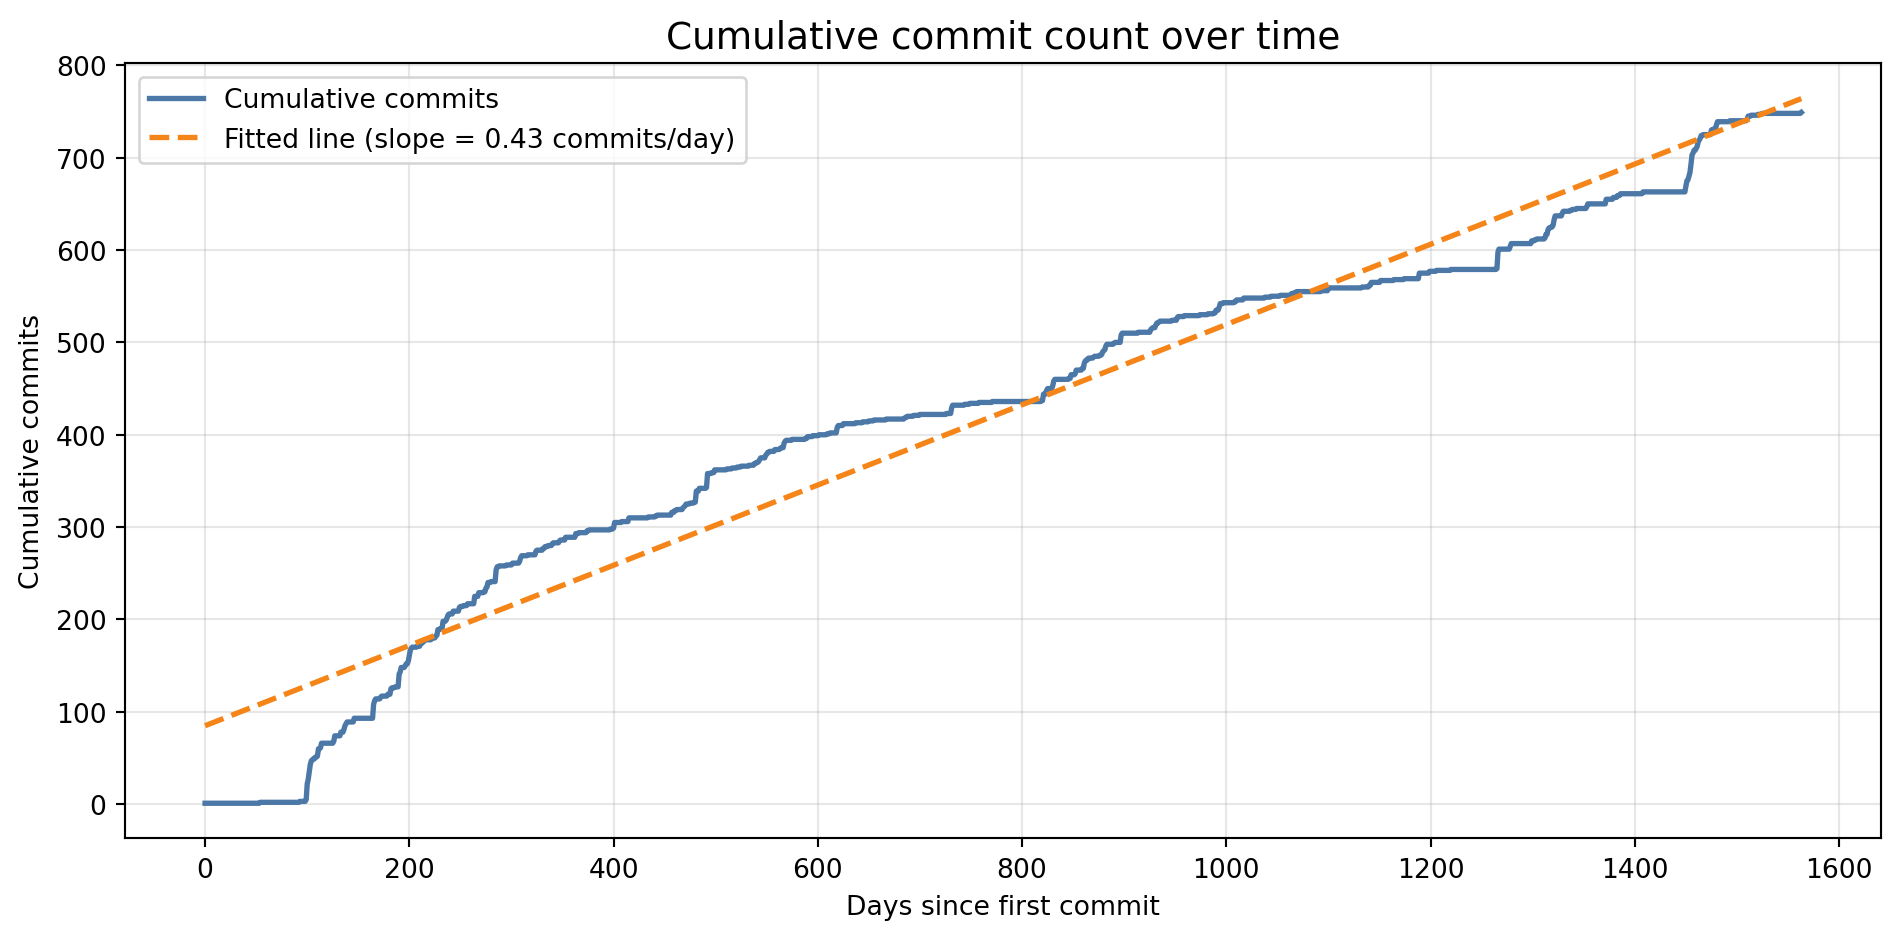

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(days, cumulative_counts, label="Cumulative commits", color="#4C78A8", lw=2)
plt.plot(days, slope * days + intercept, label=f"Fitted line (slope = {slope:.2f} commits/day)", color="#F58518", lw=2, ls="--")
plt.title("Cumulative commit count over time", fontsize=14)
plt.xlabel("Days since first commit")
plt.ylabel("Cumulative commits")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_commits.png", dpi=150, bbox_inches="tight", transparent
=True)
plt.show()

In [6]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
from sklearn.preprocessing import MinMaxScaler

# ── 1. Build an oscillatory scalar time series ────────────────────────────────
# The previous attempt embedded the raw (monotonically-increasing) commit
# timestamps directly.  A monotone signal unrolls as a *line* in R^w, with no
# loops, no H1.  For Takens embedding to reveal periodic structure the
# underlying signal must itself oscillate.  We therefore count commits per day
# and use that as the signal: it rises and falls with weekly/monthly rhythm.

ts_sorted = np.array(sorted(c.committed_date for c in commits), dtype=float)
t0        = ts_sorted[0]
span_days = int((ts_sorted[-1] - t0) / 86400) + 1

# Daily commit counts (index = integer day offset from first commit)
daily_counts = np.zeros(span_days, dtype=float)
for t in ts_sorted:
    day_idx = int((t - t0) / 86400)
    daily_counts[day_idx] += 1

# Optional: smooth with a 3-day rolling average to reduce single-day spikes
kernel = np.ones(3) / 3
signal = np.convolve(daily_counts, kernel, mode="same")

print(f"Signal length : {len(signal)} days")
print(f"Non-zero days : {np.count_nonzero(daily_counts)}")
print(f"Max commits/day: {int(daily_counts.max())}")

Signal length : 1564 days
Non-zero days : 287
Max commits/day: 18


/Users/luca/Documents/happel/quoteme.github.io/.venv/lib/python3.13/site-packages/persim/landscapes/visuals.py:310: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ls[:, 0], ls[:, 1], label=f"$\lambda_{{{depth}}}$", alpha=alpha)
/Users/luca/Documents/happel/quoteme.github.io/.venv/lib/python3.13/site-packages/persim/landscapes/visuals.py:469: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(domain, l, label=f"$\lambda_{{{depth}}}$", alpha=alpha)


In [7]:
# ── 2. Sliding-window (Takens) embedding ─────────────────────────────────────
# Window w = 14 captures ≈ two weeks so that a 7-day cycle can close into a
# loop inside the embedding space (the loop needs at least w > period points).
# Stride = 1 keeps every window; reduce if the cloud is too large.
w      = 14
stride = 1

signal_norm = MinMaxScaler().fit_transform(signal.reshape(-1, 1)).ravel()
cloud = np.array([
    signal_norm[i : i + w]
    for i in range(0, len(signal_norm) - w + 1, stride)
])
print(f"Point cloud shape : {cloud.shape}  ({cloud.shape[0]} points in ℝ^{cloud.shape[1]})")

Point cloud shape : (1551, 14)  (1551 points in ℝ^14)


In [8]:
# ── 3. Persistent homology via Ripser ─────────────────────────────────────────
result   = ripser(cloud, maxdim=1)
diagrams = result["dgms"]   # diagrams[0] = H0, diagrams[1] = H1

h0, h1 = diagrams
h0_finite = h0[np.isfinite(h0[:, 1])]
print(f"H0 finite features : {len(h0_finite)}")
print(f"H1 features        : {len(h1)}")
if len(h1):
    persistence = h1[:, 1] - h1[:, 0]
    top5 = np.sort(persistence)[::-1][:5]
    print(f"Top-5 H1 persistence values: {np.round(top5, 4)}")

H0 finite features : 1065
H1 features        : 704
Top-5 H1 persistence values: [0.3583 0.1708 0.1268 0.1217 0.1152]


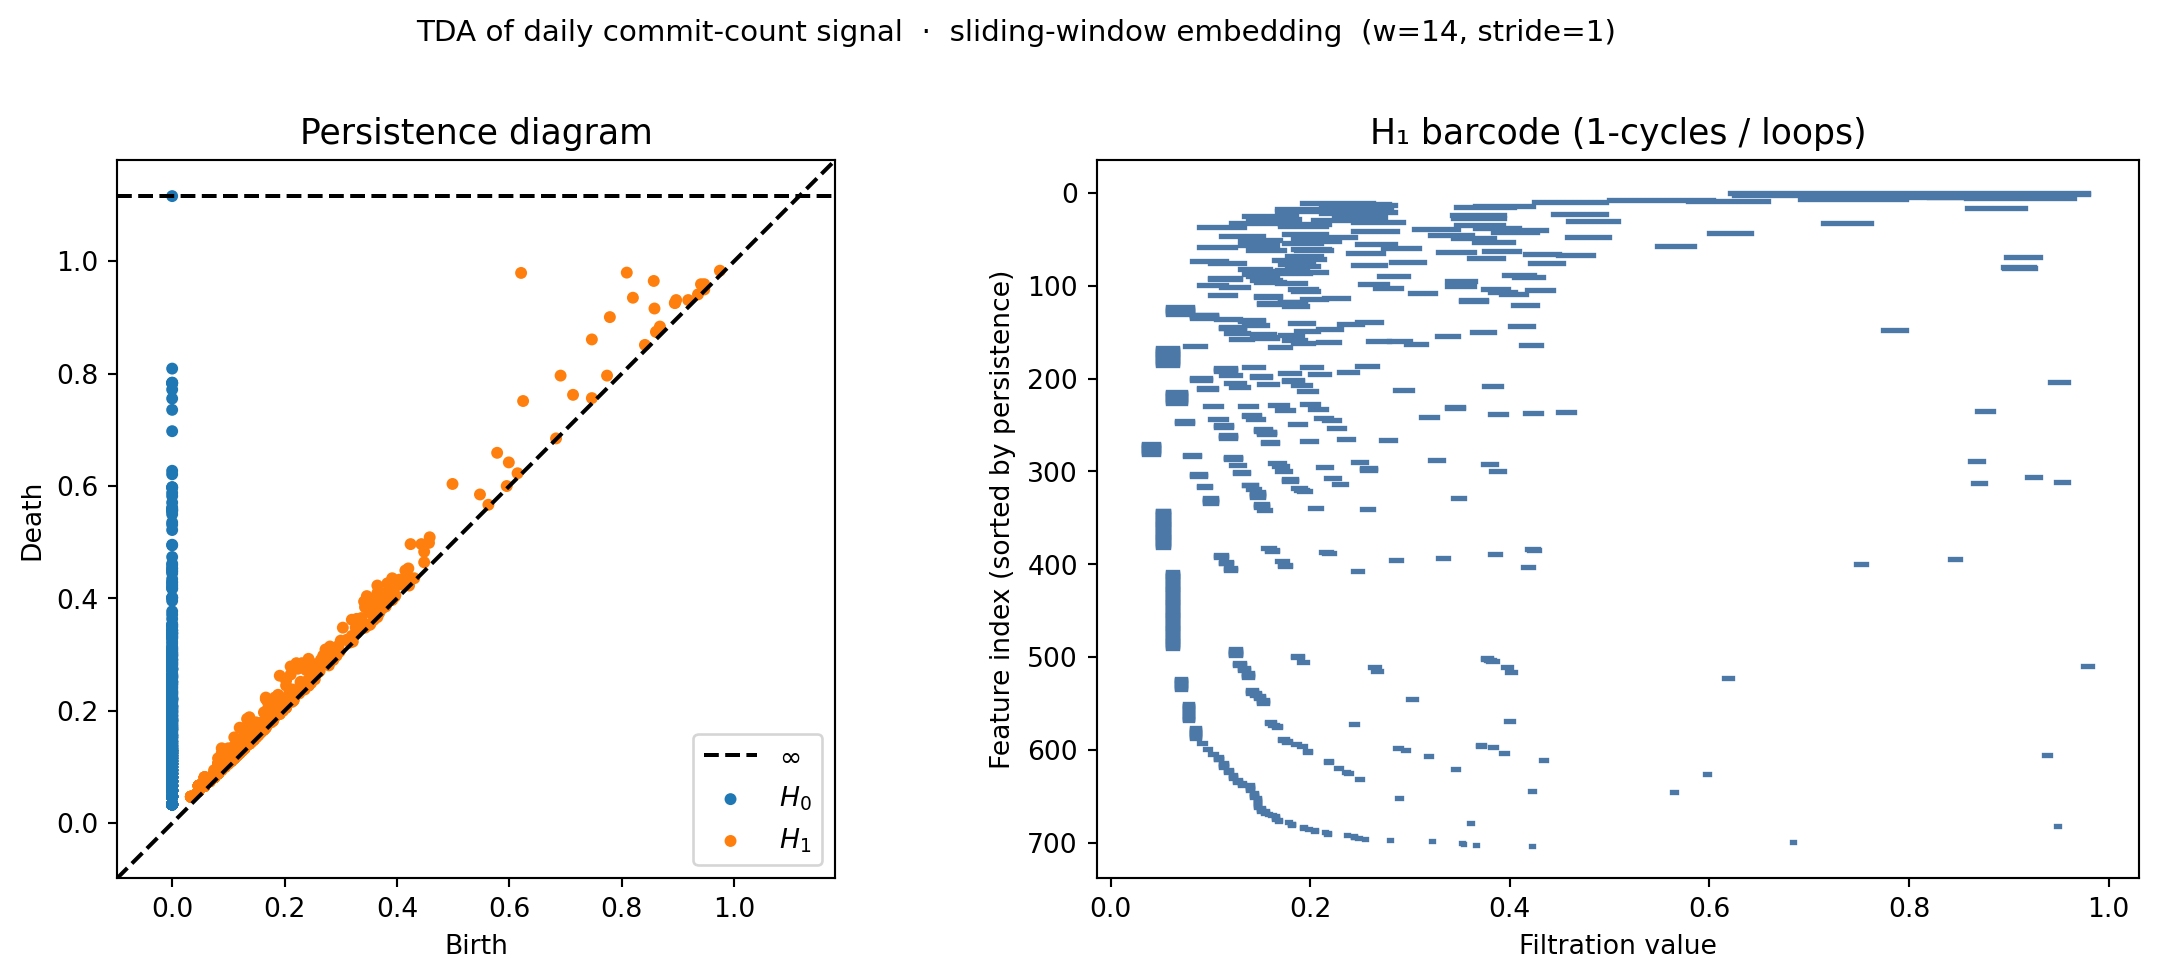

In [9]:
# ── 4. Visualise ─────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "figure.facecolor"   : "none",
    "axes.facecolor"     : "none",
    "savefig.transparent": True,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Persistence diagram
plot_diagrams(diagrams, ax=axes[0], show=False)
axes[0].set_title("Persistence diagram", fontsize=13)
axes[0].set_xlabel("Birth")
axes[0].set_ylabel("Death")

# H1 barcode (sorted by persistence)
ax = axes[1]
if len(h1):
    order = np.argsort(h1[:, 1] - h1[:, 0])[::-1]
    for rank, idx in enumerate(order):
        birth, death = h1[idx]
        ax.plot([birth, death], [rank, rank], lw=2, color="#4C78A8")
    ax.set_title("H₁ barcode (1-cycles / loops)", fontsize=13)
    ax.set_xlabel("Filtration value")
    ax.set_ylabel("Feature index (sorted by persistence)")
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, "No H₁ features detected",
            ha="center", va="center", transform=ax.transAxes, fontsize=12)
    ax.set_title("H₁ barcode", fontsize=13)

plt.suptitle(
    f"TDA of daily commit-count signal  ·  sliding-window embedding  (w={w}, stride={stride})",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig("tda_commit_times.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

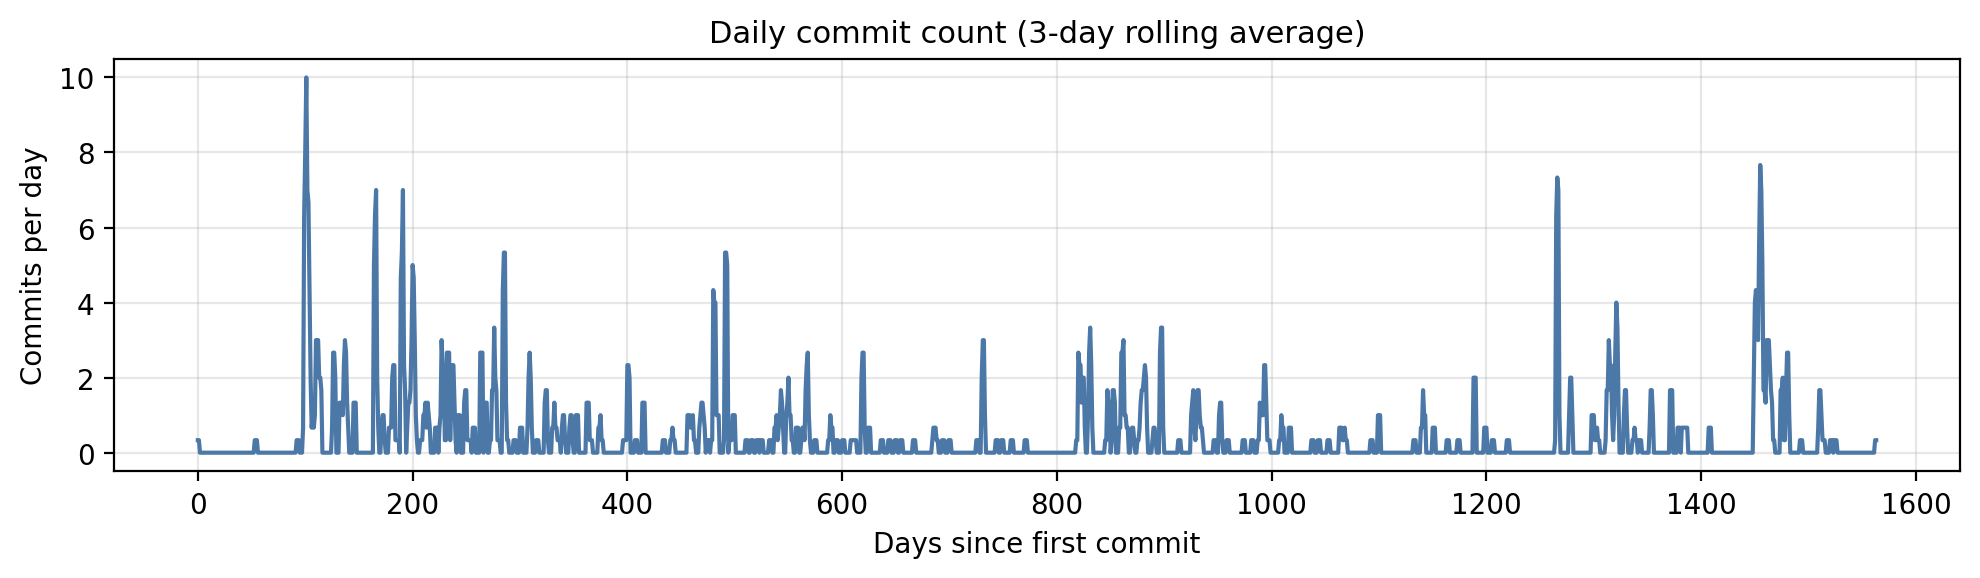

In [10]:
plt.figure(figsize=(10, 3))
plt.plot(signal, color="#4C78A8", lw=1.5)
plt.title("Daily commit count (3-day rolling average)", fontsize=11)
plt.xlabel("Days since first commit")
plt.ylabel("Commits per day")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("daily_commit_count.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

In [11]:
import re
from IPython.display import HTML

SENSITIVE = [
    "api", "key", "password", "passwd", "secret", "token", "credential",
    "private", "auth", "oauth", "ssh", "gpg", "pgp", "cert", "tls", "ssl",
    "vulnerability", "exploit", "cve", "backdoor", "leak",
]
PAT = re.compile(r"(?<!\w)(" + "|".join(SENSITIVE) + r")(?!\w)", re.IGNORECASE)

# ── 1. Commit messages ────────────────────────────────────────────────────────
msg_hits: list[tuple[str, str, list[str]]] = []
for c in commits:
    found = PAT.findall(c.message)
    if found:
        msg_hits.append((c.hexsha[:7], c.message.splitlines()[0][:80], sorted(set(w.lower() for w in found))))

# ── 2. File paths ─────────────────────────────────────────────────────────────
path_hits: list[tuple[str, list[str]]] = []
for path in all_files:
    found = PAT.findall(path)
    if found:
        path_hits.append((path, sorted(set(w.lower() for w in found))))

# ── 3. Commit diffs ───────────────────────────────────────────────────────────
CONTEXT = 60  # characters of context around each match

def diff_snippets(diff_text: str) -> list[str]:
    snippets = []
    for m in PAT.finditer(diff_text):
        start = max(0, m.start() - CONTEXT)
        end   = min(len(diff_text), m.end() + CONTEXT)
        snippet = diff_text[start:end].replace("\n", " ")
        snippets.append(f"…{snippet}…")
    return snippets[:3]  # at most 3 snippets per commit

diff_hits: list[tuple[str, str, list[str]]] = []
for c in commits:
    if not c.parents:
        continue
    try:
        diff_text = repo.git.diff(c.parents[0].hexsha, c.hexsha, unified=0)
    except Exception:
        continue
    if PAT.search(diff_text):
        snippets = diff_snippets(diff_text)
        diff_hits.append((c.hexsha[:7], c.committed_datetime.strftime("%Y-%m-%d"), snippets))

# ── Render results ────────────────────────────────────────────────────────────
def kw(words):
    return " ".join(f'<code style="color:#c0392b">{w}</code>' for w in words)

parts = []

parts.append(f"<h4>1. Commit messages: {len(msg_hits)} hit(s)</h4>")
if msg_hits:
    rows = "".join(
        f"<tr><td><code>{sha}</code></td><td>{msg}</td><td>{kw(words)}</td></tr>"
        for sha, msg, words in msg_hits
    )
    parts.append(f'<table style="font-size:0.82rem;width:100%;border-collapse:collapse">'
                 f'<thead><tr><th>SHA</th><th>Message</th><th>Keywords</th></tr></thead>'
                 f'<tbody>{rows}</tbody></table>')
else:
    parts.append("<p>✓ No sensitive keywords found in commit messages.</p>")

parts.append(f"<h4>2. File paths: {len(path_hits)} hit(s)</h4>")
if path_hits:
    rows = "".join(
        f"<tr><td><code>{path}</code></td><td>{kw(words)}</td></tr>"
        for path, words in path_hits
    )
    parts.append(f'<table style="font-size:0.82rem;width:100%;border-collapse:collapse">'
                 f'<thead><tr><th>Path</th><th>Keywords</th></tr></thead>'
                 f'<tbody>{rows}</tbody></table>')
else:
    parts.append("<p>✓ No sensitive keywords found in file paths.</p>")

parts.append(f"<h4>3. Commit diffs: {len(diff_hits)} hit(s)</h4>")
if diff_hits:
    rows = "".join(
        f"<tr><td><code>{sha}</code></td><td>{date}</td>"
        f"<td style='font-size:0.78rem'>" + "<br>".join(
            f'<span style="background:#fff3cd;padding:1px 3px;border-radius:2px">{s}</span>'
            for s in snips
        ) + "</td></tr>"
        for sha, date, snips in diff_hits
    )
    parts.append(f'<table style="font-size:0.82rem;width:100%;border-collapse:collapse">'
                 f'<thead><tr><th>SHA</th><th>Date</th><th>Context snippets</th></tr></thead>'
                 f'<tbody>{rows}</tbody></table>')
else:
    parts.append("<p>✓ No sensitive keywords found in diffs.</p>")

HTML("\n".join(parts))